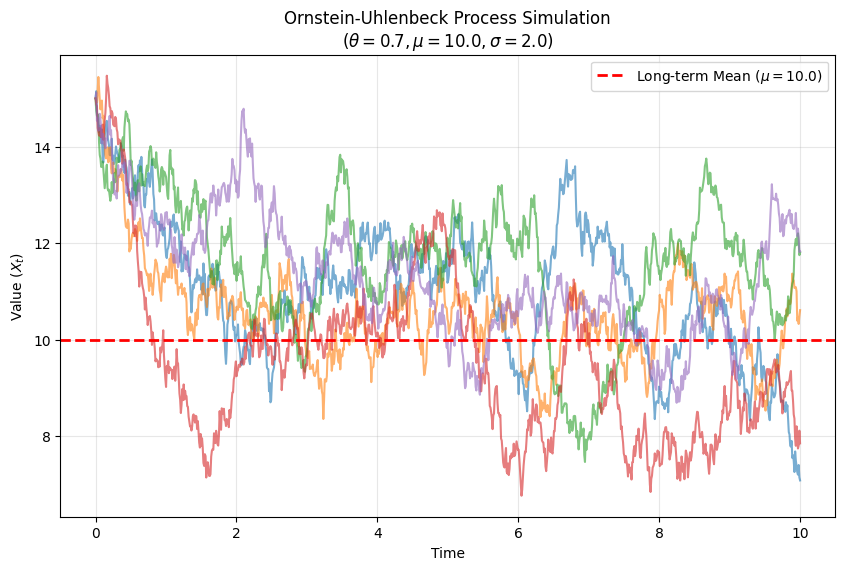

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ou_process(theta, mu, sigma, x0, dt, T, n_simulations=1):
    """
    模擬 Ornstein-Uhlenbeck 過程
    
    參數:
    theta (float): 均值回歸速度
    mu (float): 長期均值
    sigma (float): 波動率
    x0 (float): 初始值
    dt (float): 時間步長
    T (float): 總時間
    n_simulations (int): 模擬的路徑數量
    
    返回:
    time (array): 時間軸
    x (array): 模擬的路徑數據 (shape: [steps, n_simulations])
    """
    N = int(T / dt)  # 總步數
    time = np.linspace(0, T, N)
    
    # 初始化陣列
    x = np.zeros((N, n_simulations))
    x[0] = x0
    
    # 執行 Euler-Maruyama 迭代
    for t in range(1, N):
        # 上一時刻的值
        x_prev = x[t-1]
        
        # 產生隨機雜訊 (標準常態分佈)
        dw = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=n_simulations)
        
        # 核心公式: dX = theta*(mu - X)*dt + sigma*dW
        dx = theta * (mu - x_prev) * dt + sigma * dw
        
        # 更新 X
        x[t] = x_prev + dx
        
    return time, x

# --- 設定參數 ---
theta = 0.7    # 回歸速度 (越大拉回越快)
mu = 10.0      # 長期均值 (目標值)
sigma = 2.0    # 波動率 (雜訊大小)
x0 = 15.0      # 初始值 (故意設得離 mu 遠一點，觀察回歸)
dt = 0.01      # 時間步長
T = 10.0       # 總時間

# --- 執行模擬 ---
# 模擬 5 條路徑以觀察隨機性
time_axis, ou_paths = simulate_ou_process(theta, mu, sigma, x0, dt, T, n_simulations=5)

# --- 繪圖 ---
plt.figure(figsize=(10, 6))
plt.plot(time_axis, ou_paths, alpha=0.6, lw=1.5)

# 畫出長期均值 mu 的虛線
plt.axhline(y=mu, color='r', linestyle='--', linewidth=2, label=f'Long-term Mean ($\mu={mu}$)')

plt.title(f'Ornstein-Uhlenbeck Process Simulation\n($\\theta={theta}, \mu={mu}, \sigma={sigma}$)')
plt.xlabel('Time')
plt.ylabel('Value ($X_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()